# Day 5 模块 2：场景证据（汇报素材）

老板要的是**可复述的发现**，不是一长串代码。
工具仍是 Day 2 的分组与交叉，问题换成经营语言。


In [17]:
from pathlib import Path
import pandas as pd

candidate_paths = [
    Path('day5_cafe_sales.csv'),
    Path('day5') / 'day5_cafe_sales.csv',
    Path('教学课程') / 'day5' / 'day5_cafe_sales.csv',
]
for path in candidate_paths:
    if path.exists():
        csv_path = path
        break
else:
    raise FileNotFoundError('未找到 day5_cafe_sales.csv')

df = pd.read_csv(csv_path)
print(csv_path.resolve())
print('shape:', df.shape)
df.head()


D:\obi\熵学院\授课\机器学习-6小时\教学课程\day5\day5_cafe_sales.csv
shape: (200, 12)


,day,weather,weather_label,temp,is_weekend,promotion,quality,price,location,competitors,holiday,sales
0,1,1,多云,33.5,0,1,8.27,24.5,5.78,2,0,3249
1,2,2,阴,6.7,0,1,9.57,22.0,9.96,0,0,4700
2,3,0,晴,23.4,0,0,7.11,27.9,7.28,5,0,2071
3,4,2,阴,6.4,0,0,6.65,23.0,9.74,3,0,2370
4,5,0,晴,11.9,0,0,8.60,31.8,9.17,2,0,2847


In [18]:
weather_score_map = {'晴': 1.0, '多云': 0.8, '阴': 0.6, '小雨': 0.4, '大雨': 0.3}
df = df.copy()
df['weather_score'] = df['weather_label'].map(weather_score_map)
df['weekend_label'] = df['is_weekend'].map({0: '工作日', 1: '周末'})
df['promo_label'] = df['promotion'].map({0: '无促销', 1: '有促销'})
print(df[['day', 'weather_label', 'weekend_label', 'promo_label', 'sales']].head())
print('平均营收:', round(df['sales'].mean(), 1))


   day weather_label weekend_label promo_label  sales
0    1            多云           工作日         有促销   3249
1    2             阴           工作日         有促销   4700
2    3             晴           工作日         无促销   2071
3    4             阴           工作日         无促销   2370
4    5             晴           工作日         无促销   2847
平均营收: 2751.2


## 1. 整体画像（开场 20 秒可用）


In [19]:
summary = {
    '天数': len(df),
    '平均营收': round(df['sales'].mean(), 1),
    '中位营收': round(df['sales'].median(), 1),
    '最高营收': int(df['sales'].max()),
    '最低营收': int(df['sales'].min()),
}
summary


{'天数': 200,
 '平均营收': np.float64(2751.2),
 '中位营收': np.float64(2585.5),
 '最高营收': 5939,
 '最低营收': 1291}

## 2. 单因子：天气 / 周末 / 促销


In [20]:
print('【天气】')
print(df.groupby('weather_label')['sales'].agg(['mean', 'count']).round(1).sort_values('mean', ascending=False))
print()
print('【周末】')
print(df.groupby('weekend_label')['sales'].agg(['mean', 'count']).round(1))
print()
print('【促销】')
print(df.groupby('promo_label')['sales'].agg(['mean', 'count']).round(1))


【天气】
                 mean  count
weather_label               
晴              2940.9     80
多云             2828.9     43
阴              2623.1     38
小雨             2439.7     23
大雨             2345.6     16

【周末】
                 mean  count
weekend_label               
周末             2910.6     56
工作日            2689.2    144

【促销】
               mean  count
promo_label               
无促销          2571.8    149
有促销          3275.2     51


## 3. 交叉：周末 × 促销（更像经营问题）


In [21]:
cross = df.pivot_table(
    values='sales', index='weekend_label',
    columns='promo_label', aggfunc='mean',
).round(1)
cross


promo_label,无促销,有促销
weekend_label,,
周末,2833.8,3192.2
工作日,2462.0,3300.7


## 4. 最好 / 最差几天（举例用）


In [22]:
cols = ['day', 'weather_label', 'weekend_label', 'promo_label',
        'price', 'competitors', 'quality', 'sales']
print('TOP 5')
print(df.nlargest(5, 'sales')[cols].to_string(index=False))
print()
print('BOTTOM 5')
print(df.nsmallest(5, 'sales')[cols].to_string(index=False))


TOP 5
 day weather_label weekend_label promo_label  price  competitors  quality  sales
 200             晴           工作日         有促销   23.2            1     9.07   5939
 124             晴           工作日         有促销   22.9            0     7.33   5059
  16             晴           工作日         有促销   30.3            0     7.23   5015
 126             阴            周末         无促销   26.2            0     9.33   4840
   2             阴           工作日         有促销   22.0            0     9.57   4700

BOTTOM 5
 day weather_label weekend_label promo_label  price  competitors  quality  sales
  95             阴           工作日         无促销   37.4            5     6.68   1291
  38             阴           工作日         无促销   34.1            5     7.35   1370
  18            大雨           工作日         无促销   37.8            3     7.86   1393
 143             阴           工作日         无促销   34.5            5     9.27   1474
 136            小雨           工作日         无促销   38.0            4     7.04   1486


## 5. 可选图（汇报投影用一张即可）


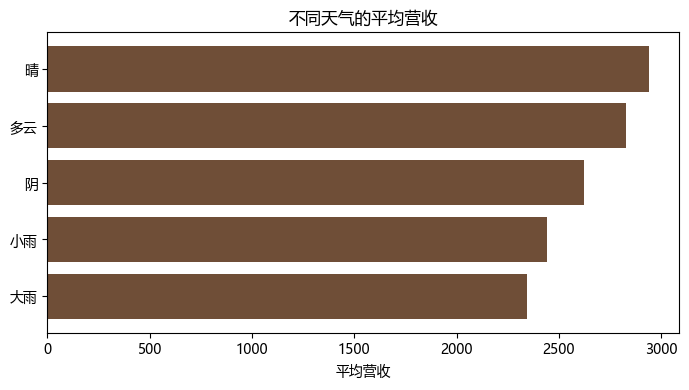

In [23]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

s = df.groupby('weather_label')['sales'].mean().sort_values()
plt.figure(figsize=(7, 4))
plt.barh(s.index.astype(str), s.values, color='#6f4e37')
plt.xlabel('平均营收')
plt.title('不同天气的平均营收')
plt.tight_layout()
plt.show()


## 6. 写成汇报素材（发现 → 解释 → 行动）

至少 2 条，**每条都要有数字**。这些句子下午要出现在「给老板讲」里。


In [24]:
# 汇报素材 1/2/3
